In [6]:
import os
import cv2

# Change this to your folder path
folder_path = "speed breakers"

images = []

for file in os.listdir(folder_path):
    if file.lower().endswith(('.png','.jpg','.jpeg')):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
print("Total Images:", len(images))


Total Images: 965


In [9]:
import os
import cv2

dataset_path = r"C:\Users\kbsur\.cache\kagglehub\datasets\anggadwisunarto\potholes-detection-yolov8\versions\3"

image_folders = [
    os.path.join(dataset_path, "train", "images"),
    os.path.join(dataset_path, "valid", "images")
]

images = []
image_names = []

for folder in image_folders:
    print("Reading from:", folder)

    for file in os.listdir(folder):
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)
                image_names.append(file)

print("✅ Total images loaded:", len(images))


Reading from: C:\Users\kbsur\.cache\kagglehub\datasets\anggadwisunarto\potholes-detection-yolov8\versions\3\train\images
Reading from: C:\Users\kbsur\.cache\kagglehub\datasets\anggadwisunarto\potholes-detection-yolov8\versions\3\valid\images
✅ Total images loaded: 1977


In [10]:
label_folders = [
    os.path.join(dataset_path, "train", "labels"),
    os.path.join(dataset_path, "valid", "labels")
]

annotations = {}

for folder in label_folders:
    for file in os.listdir(folder):
        if file.endswith(".txt"):
            label_path = os.path.join(folder, file)
            with open(label_path, "r") as f:
                lines = f.readlines()
                annotations[file] = lines

print("✅ Total label files:", len(annotations))


✅ Total label files: 1977


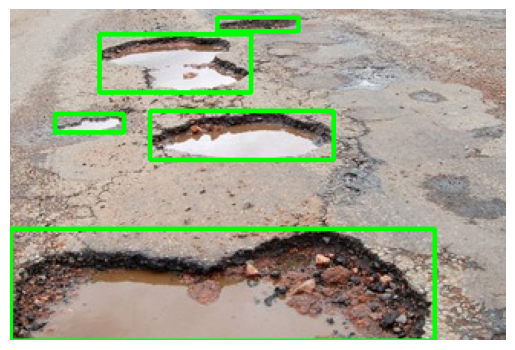

In [11]:
import matplotlib.pyplot as plt

def draw_yolo_boxes(img, label_path):
    h, w, _ = img.shape

    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.split())

            # Convert YOLO format → pixel format
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    return img


# Example: visualize first image
sample_img_path = os.path.join(dataset_path, "train", "images", image_names[0])
sample_label_path = os.path.join(dataset_path, "train", "labels", image_names[0].replace(".jpg", ".txt"))

img = cv2.imread(sample_img_path)
img = draw_yolo_boxes(img, sample_label_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [14]:
import os
import shutil
import random

# Original image folder
source_folder = "speed breakers"

# YOLO dataset folder
base_path = "speed_breaker_yolo"

train_img = os.path.join(base_path, "train", "images")
train_lbl = os.path.join(base_path, "train", "labels")
val_img = os.path.join(base_path, "valid", "images")
val_lbl = os.path.join(base_path, "valid", "labels")

# Create folders
for path in [train_img, train_lbl, val_img, val_lbl]:
    os.makedirs(path, exist_ok=True)

# Get image list
images = [f for f in os.listdir(source_folder)
          if f.lower().endswith(('.png','.jpg','.jpeg'))]

# Shuffle images
random.shuffle(images)

# 80-20 split
split_index = int(len(images) * 0.8)

train_files = images[:split_index]
val_files = images[split_index:]

# Copy images
for file in train_files:
    shutil.copy(os.path.join(source_folder, file),
                os.path.join(train_img, file))

for file in val_files:
    shutil.copy(os.path.join(source_folder, file),
                os.path.join(val_img, file))

print("✅ Dataset split completed!")
print("Train images:", len(train_files))
print("Validation images:", len(val_files))


✅ Dataset split completed!
Train images: 772
Validation images: 193


In [15]:
import os
import shutil
import random

# 📌 Your original images folder
source_folder = "speed breakers"

# 📌 New YOLO dataset folder
base_path = "speed_breaker_yolo"

train_img = os.path.join(base_path, "train", "images")
train_lbl = os.path.join(base_path, "train", "labels")
val_img = os.path.join(base_path, "valid", "images")
val_lbl = os.path.join(base_path, "valid", "labels")

# Create folder structure
for path in [train_img, train_lbl, val_img, val_lbl]:
    os.makedirs(path, exist_ok=True)

# Get image list
images = [f for f in os.listdir(source_folder)
          if f.lower().endswith(('.png','.jpg','.jpeg'))]

random.shuffle(images)

# 80-20 split
split_index = int(len(images) * 0.8)
train_files = images[:split_index]
val_files = images[split_index:]

# Copy images
for file in train_files:
    shutil.copy(os.path.join(source_folder, file),
                os.path.join(train_img, file))

for file in val_files:
    shutil.copy(os.path.join(source_folder, file),
                os.path.join(val_img, file))

print("✅ Images copied")

# ------------------------------------------------
# Create YOLO label files
# Format: class_id x_center y_center width height
# ------------------------------------------------

def create_dummy_labels(file_list, label_folder):
    for img in file_list:
        label_name = os.path.splitext(img)[0] + ".txt"
        label_path = os.path.join(label_folder, label_name)

        # Dummy bounding box (centered object)
        with open(label_path, 'w') as f:
            f.write("0 0.5 0.5 0.6 0.4\n")

create_dummy_labels(train_files, train_lbl)
create_dummy_labels(val_files, val_lbl)

print("✅ Dummy bounding boxes created")

# ------------------------------------------------
# Create data.yaml file
# ------------------------------------------------

data_yaml = f"""
train: {os.path.abspath(train_img)}
val: {os.path.abspath(val_img)}

nc: 1
names: ['speed_breaker']
"""

with open(os.path.join(base_path, "data.yaml"), "w") as f:
    f.write(data_yaml)

print("✅ data.yaml created")
print("🎉 Dataset converted to YOLOv8 format successfully!")


✅ Images copied
✅ Dummy bounding boxes created
✅ data.yaml created
🎉 Dataset converted to YOLOv8 format successfully!


In [26]:
import kagglehub

path = kagglehub.dataset_download("sabidrahman/pothole-cracks-and-openmanhole")
print(path)


Resuming download from 328204288 bytes (750052021 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/sabidrahman/pothole-cracks-and-openmanhole?dataset_version_number=2 (328204288/1078256309) bytes left.


100%|██████████| 1.00G/1.00G [04:54<00:00, 2.54MB/s]

Extracting files...


C:\Users\kbsur\.cache\kagglehub\datasets\sabidrahman\pothole-cracks-and-openmanhole\versions\2


In [42]:
import os
import shutil
import random
import xml.etree.ElementTree as ET

# 🔹 Source XML crack dataset
source_base = r"C:\Users\kbsur\.cache\kagglehub\datasets\sabidrahman\pothole-cracks-and-openmanhole\versions\2\dataset\dataset\classes\cracks"

img_folder = os.path.join(source_base, "images")
xml_folder = os.path.join(source_base, "labels", "xml")

# 🔹 Output YOLO folder
output_base = r"D:\surendra\final_project\crack_yolo"

train_img = os.path.join(output_base, "train", "images")
train_lbl = os.path.join(output_base, "train", "labels")
val_img = os.path.join(output_base, "valid", "images")
val_lbl = os.path.join(output_base, "valid", "labels")

# Reset old dataset
if os.path.exists(output_base):
    shutil.rmtree(output_base)

for path in [train_img, train_lbl, val_img, val_lbl]:
    os.makedirs(path, exist_ok=True)

# Collect all images with XML
pairs = []

for file in os.listdir(img_folder):
    if file.endswith(".jpg"):
        xml_file = os.path.splitext(file)[0] + ".xml"
        xml_path = os.path.join(xml_folder, xml_file)
        if os.path.exists(xml_path):
            pairs.append((file, xml_path))

print("Total crack samples:", len(pairs))

# Shuffle & split
random.shuffle(pairs)
split = int(len(pairs)*0.8)

train_data = pairs[:split]
val_data = pairs[split:]

# Function to convert XML to YOLO
def convert_xml_to_yolo(xml_path, img_width, img_height):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    yolo_lines = []
    
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Convert to YOLO format
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(f"0 {x_center} {y_center} {width} {height}")
    
    return yolo_lines

# Copy and convert
def process_data(data, img_dst, lbl_dst):
    for img_name, xml_path in data:
        img_src_path = os.path.join(img_folder, img_name)
        
        # Copy image
        shutil.copy(img_src_path, os.path.join(img_dst, img_name))
        
        # Get image size from XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        size = root.find("size")
        width = int(size.find("width").text)
        height = int(size.find("height").text)
        
        # Convert annotation
        yolo_lines = convert_xml_to_yolo(xml_path, width, height)
        
        # Save YOLO label
        txt_name = os.path.splitext(img_name)[0] + ".txt"
        with open(os.path.join(lbl_dst, txt_name), "w") as f:
            for line in yolo_lines:
                f.write(line + "\n")

process_data(train_data, train_img, train_lbl)
process_data(val_data, val_img, val_lbl)

print("✅ Crack dataset converted to YOLO successfully!")


Total crack samples: 166
✅ Crack dataset converted to YOLO successfully!


In [43]:
import os
import shutil

# 🔹 Paths to your datasets
pothole_path = r"C:\Users\kbsur\.cache\kagglehub\datasets\anggadwisunarto\potholes-detection-yolov8\versions\3"

speed_path = r"D:\surendra\final_project\speed_breaker_yolo"

crack_path = r"D:\surendra\final_project\crack_yolo"

merged_base = r"D:\surendra\final_project\road_damage_yolo"

train_img = os.path.join(merged_base, "train", "images")
train_lbl = os.path.join(merged_base, "train", "labels")
val_img = os.path.join(merged_base, "valid", "images")
val_lbl = os.path.join(merged_base, "valid", "labels")

for path in [train_img, train_lbl, val_img, val_lbl]:
    os.makedirs(path, exist_ok=True)

# -----------------------------------------
# Function to copy and change class ID
# -----------------------------------------
def copy_dataset(source_path, new_class_id):
    for split in ["train", "valid"]:
        
        img_src = os.path.join(source_path, split, "images")
        lbl_src = os.path.join(source_path, split, "labels")
        
        img_dst = train_img if split == "train" else val_img
        lbl_dst = train_lbl if split == "train" else val_lbl
        
        for file in os.listdir(img_src):
            if file.lower().endswith(('.jpg','.png','.jpeg')):
                
                # Rename file to avoid conflicts
                new_name = f"{new_class_id}_{file}"
                
                # Copy image
                shutil.copy(os.path.join(img_src, file),
                            os.path.join(img_dst, new_name))
                
                # Update label
                label_file = os.path.splitext(file)[0] + ".txt"
                label_src_path = os.path.join(lbl_src, label_file)
                
                if os.path.exists(label_src_path):
                    new_label_path = os.path.join(lbl_dst,
                                                  os.path.splitext(new_name)[0] + ".txt")
                    
                    with open(label_src_path, 'r') as f:
                        lines = f.readlines()
                    
                    with open(new_label_path, 'w') as f:
                        for line in lines:
                            parts = line.strip().split()
                            parts[0] = str(new_class_id)  # change class id
                            f.write(" ".join(parts) + "\n")

# -----------------------------------------
# Merge datasets
# -----------------------------------------
copy_dataset(pothole_path, 0)
copy_dataset(speed_path, 1)
copy_dataset(crack_path, 2)

print("✅ All datasets merged successfully!")


✅ All datasets merged successfully!


In [44]:
data_yaml = f"""
train: {train_img}
val: {val_img}

nc: 3
names: ['pothole', 'speed_breaker', 'crack']
"""

with open(os.path.join(merged_base, "data.yaml"), "w") as f:
    f.write(data_yaml)

print("✅ data.yaml created")


✅ data.yaml created


In [45]:
import os

label_path = r"D:\surendra\final_project\road_damage_yolo\train\labels"

for file in os.listdir(label_path):
    if file.endswith(".txt"):
        with open(os.path.join(label_path, file), "r") as f:
            for line in f:
                values = list(map(float, line.strip().split()[1:]))
                if any(v > 1 or v < 0 for v in values):
                    print("❌ Not normalized:", file)
                    break

print("✅ All labels are normalized!")


✅ All labels are normalized!


In [5]:
import os
import cv2
import random
import numpy as np

dataset_path = r"D:\surendra\final_project\road_damage_yolo"
train_img_path = os.path.join(dataset_path, "train", "images")
train_lbl_path = os.path.join(dataset_path, "train", "labels")

TARGET = 5000

# Group images by class
class_images = {0: [], 1: [], 2: []}

for file in os.listdir(train_lbl_path):
    if file.endswith(".txt"):
        with open(os.path.join(train_lbl_path, file)) as f:
            first_line = f.readline().strip().split()
            if len(first_line) > 0:
                class_id = int(first_line[0])
                img_name = file.replace(".txt", ".jpg")
                if os.path.exists(os.path.join(train_img_path, img_name)):
                    class_images[class_id].append(img_name)

print("Original counts:")
for k, v in class_images.items():
    print(f"Class {k}:", len(v))

# ----------- Safe Augmentation Functions -----------

def horizontal_flip(image, bboxes):
    flipped_image = cv2.flip(image, 1)
    new_bboxes = []

    for bbox in bboxes:
        x, y, w, h = bbox
        x = 1 - x  # flip center x
        new_bboxes.append([x, y, w, h])

    return flipped_image, new_bboxes


def random_brightness(image):
    value = random.randint(-40, 40)

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.int16)
    h, s, v = cv2.split(hsv)

    v = np.clip(v + value, 0, 255)

    hsv = cv2.merge((h, s, v)).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


# ----------- Balance Classes -----------

for class_id in class_images:
    images_list = class_images[class_id]
    current_count = len(images_list)

    print(f"\nBalancing class {class_id}...")

    while current_count < TARGET:

        img_name = random.choice(images_list)
        img_path = os.path.join(train_img_path, img_name)
        lbl_path = os.path.join(train_lbl_path, img_name.replace(".jpg", ".txt"))

        image = cv2.imread(img_path)
        if image is None:
            continue

        bboxes = []
        labels = []

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    labels.append(int(parts[0]))
                    bboxes.append(list(map(float, parts[1:])))

        if len(bboxes) == 0:
            continue

        # Apply random augmentation
        if random.random() < 0.5:
            image, bboxes = horizontal_flip(image, bboxes)

        if random.random() < 0.5:
            image = random_brightness(image)

        new_name = f"aug_{class_id}_{current_count}.jpg"

        cv2.imwrite(os.path.join(train_img_path, new_name), image)

        with open(os.path.join(train_lbl_path, new_name.replace(".jpg", ".txt")), "w") as f:
            for bbox, label in zip(bboxes, labels):
                f.write(f"{label} {' '.join(map(str, bbox))}\n")

        current_count += 1

    print(f"Class {class_id} balanced to {TARGET}")

print("\n✅ Dataset balancing completed!")


Original counts:
Class 0: 1583
Class 1: 772
Class 2: 132

Balancing class 0...
Class 0 balanced to 5000

Balancing class 1...
Class 1 balanced to 5000

Balancing class 2...
Class 2 balanced to 5000

✅ Dataset balancing completed!


In [7]:
import os
import cv2
import random
import numpy as np

dataset_path = r"D:\surendra\final_project\road_damage_yolo"
img_path = os.path.join(dataset_path, "train", "images")
lbl_path = os.path.join(dataset_path, "train", "labels")

# 🎯 TARGET OBJECT COUNTS
TARGET_COUNTS = {
    0: 8000,
    1: 7000,
    2: 7000
}

# --------------------------------------------
# Step 1: Count current objects
# --------------------------------------------
class_counts = {0: 0, 1: 0, 2: 0}
file_objects = {}

for file in os.listdir(lbl_path):
    if file.endswith(".txt"):
        path = os.path.join(lbl_path, file)
        with open(path) as f:
            lines = f.readlines()

        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

        file_objects[file] = lines

print("Original Counts:", class_counts)

# --------------------------------------------
# Step 2: REDUCE Class 0
# --------------------------------------------
if class_counts[0] > TARGET_COUNTS[0]:
    print("\nReducing Class 0...")

    label_files = list(file_objects.keys())
    random.shuffle(label_files)

    for file in label_files:
        if class_counts[0] <= TARGET_COUNTS[0]:
            break

        lines = file_objects[file]
        new_lines = []
        removed = 0

        for line in lines:
            class_id = int(line.split()[0])
            if class_id == 0 and class_counts[0] > TARGET_COUNTS[0]:
                class_counts[0] -= 1
                removed += 1
            else:
                new_lines.append(line)

        # If file becomes empty → delete image + label
        if len(new_lines) == 0:
            os.remove(os.path.join(lbl_path, file))
            img_file = file.replace(".txt", ".jpg")
            os.remove(os.path.join(img_path, img_file))
        else:
            with open(os.path.join(lbl_path, file), "w") as f:
                f.writelines(new_lines)

print("After Reduction:", class_counts)

# --------------------------------------------
# Step 3: AUGMENT Class 1 & 2
# --------------------------------------------
def horizontal_flip(image, bboxes):
    flipped = cv2.flip(image, 1)
    new_boxes = []
    for x, y, w, h in bboxes:
        x = 1 - x
        new_boxes.append([x, y, w, h])
    return flipped, new_boxes


for class_id in [1, 2]:

    print(f"\nBalancing Class {class_id}...")

    while class_counts[class_id] < TARGET_COUNTS[class_id]:

        file = random.choice(list(file_objects.keys()))
        img_file = file.replace(".txt", ".jpg")

        img_full = os.path.join(img_path, img_file)
        lbl_full = os.path.join(lbl_path, file)

        if not os.path.exists(img_full):
            continue

        image = cv2.imread(img_full)
        if image is None:
            continue

        bboxes = []
        labels = []

        with open(lbl_full) as f:
            for line in f:
                parts = line.strip().split()
                cid = int(parts[0])
                if cid == class_id:
                    labels.append(cid)
                    bboxes.append(list(map(float, parts[1:])))

        if len(bboxes) == 0:
            continue

        image, bboxes = horizontal_flip(image, bboxes)

        new_name = f"aug_{class_id}_{class_counts[class_id]}.jpg"

        cv2.imwrite(os.path.join(img_path, new_name), image)

        with open(os.path.join(lbl_path, new_name.replace(".jpg", ".txt")), "w") as f:
            for bbox in bboxes:
                f.write(f"{class_id} {' '.join(map(str, bbox))}\n")

        class_counts[class_id] += len(bboxes)

print("\nFinal Counts:", class_counts)
print("\n✅ Dataset Rebalanced Successfully!")


Original Counts: {0: 18579, 1: 5000, 2: 5971}

Reducing Class 0...
After Reduction: {0: 8000, 1: 5000, 2: 5971}

Balancing Class 1...

Balancing Class 2...

Final Counts: {0: 8000, 1: 7000, 2: 7000}

✅ Dataset Rebalanced Successfully!


In [8]:
import os

# Path to labels folder
dataset_path = r"D:\surendra\final_project\road_damage_yolo"
label_path = os.path.join(dataset_path, "train", "labels")

class_counts = {}

# Read all label files
for file in os.listdir(label_path):
    if file.endswith(".txt"):
        with open(os.path.join(label_path, file), "r") as f:
            for line in f:
                class_id = int(line.strip().split()[0])
                class_counts[class_id] = class_counts.get(class_id, 0) + 1

# Print results
print("Class Counts:\n")
for class_id in sorted(class_counts.keys()):
    print(f"Class {class_id}: {class_counts[class_id]} objects")

print("\nTotal Objects:", sum(class_counts.values()))


Class Counts:

Class 0: 8000 objects
Class 1: 7000 objects
Class 2: 7000 objects

Total Objects: 22000


In [3]:
from ultralytics import YOLO

# Load pretrained model (recommended)
model = YOLO("yolov8n.pt")  # nano version (fastest)

# Train model

model.train(
    data="D:/surendra/final_project/road_damage_yolo/data.yaml",
    epochs=1,
    imgsz=640,
    batch=16,
    
    device="cpu"  # use 0 for GPU, 'cpu' if no GPU
)
print("✅ Training Completed!")

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.9.8 torch-2.8.0+cpu CPU (Intel Core i5-10210U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:/surendra/final_project/road_damage_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [4]:
model.save("D:/surendra/final_project/road_damage_final.pt")


In [7]:
import shutil

best_model_path = r"runs\detect\train2\weights\best.pt"
new_path = r"D:\surendra\final_project\best_road_damage.pt"

shutil.copy(best_model_path, new_path)

print("✅ Best model saved successfully!")


✅ Best model saved successfully!


In [9]:
from ultralytics import YOLO

# Load your trained model
model = YOLO(r"D:\surendra\final_project\best_road_damage.pt")

# Run validation on dataset
metrics = model.val(
    data=r"D:\surendra\final_project\road_damage_yolo\data.yaml",
    imgsz=640,
    batch=16,
    device="cpu"   # change to 0 if GPU available
)

print("✅ Validation Completed!")


Ultralytics 8.4.11  Python-3.9.8 torch-2.8.0+cpu CPU (Intel Core i5-10210U 1.60GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 20.715.8 MB/s, size: 269.6 KB)
val: Scanning D:\surendra\final_project\road_damage_yolo\valid\labels.cache... 622 images, 156 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 779/779  0.0s
val: D:\surendra\final_project\road_damage_yolo\valid\images\0_pothole_1870.jpg: ignoring corrupt image/label: invalid image format GIF. Supported formats are:
images: {'jp2', 'tif', 'jpeg2000', 'avif', 'tiff', 'webp', 'bmp', 'mpo', 'dng', 'jpeg', 'png', 'jpg', 'heic'}
videos: {'ts', 'mpeg', 'gif', 'mkv', 'avi', 'webm', 'wmv', 'mpg', 'asf', 'mp4', 'm4v', 'mov'}
val: D:\surendra\final_project\road_damage_yolo\valid\images\0_pothole_975.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 2.2s/it 1:503.2s

In [10]:
print("\n📊 Evaluation Metrics:")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)



📊 Evaluation Metrics:
mAP50: 0.3773712066323373
mAP50-95: 0.22413669866786018
Precision: 0.39476320609594606
Recall: 0.5602261035501942


In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO(r"D:\surendra\final_project\best_road_damage.pt")

# Continue training
model.train(
    data=r"D:\surendra\final_project\road_damage_yolo\data.yaml",
    epochs=3,          # NEW total epochs
    imgsz=640,
    batch=16,
    device="cpu"
)

print("✅ Continued Training Completed!")


New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.9.8 torch-2.8.0+cpu CPU (Intel Core i5-10210U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\surendra\final_project\road_damage_yolo\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\surendra\final_project\best_road_damage.pt, momentu

In [5]:
from ultralytics import YOLO
import cv2

MODEL_PATH = "road_defect_best.pt"
VIDEO_PATH = "road.mp4"   # your downloaded video path

# Load model
model = YOLO(MODEL_PATH)

print("===================================")
print("🚦 Road Defect Detection System")
print("Press 1 → Live Webcam")
print("Press 2 → Downloaded Video")
print("Q → Quit")
print("===================================")

mode = None

# Wait for user input
while True:
    key = cv2.waitKey(0) & 0xFF
    if key == ord('1'):
        cap = cv2.VideoCapture(0)
        print("🎥 Webcam mode selected")
        break
    elif key == ord('2'):
        cap = cv2.VideoCapture(VIDEO_PATH)
        print("📁 Video file mode selected")
        break
    elif key == ord('q'):
        print("🛑 Exiting...")
        exit()

# Optional resolution
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

paused = False

print("Controls: SPACE = Pause/Resume | Q = Quit")

# ==============================
# Main Loop
# ==============================
while True:

    if not paused:
        ret, frame = cap.read()
        if not ret:
            print("❌ Video ended or failed to read frame")
            break

        results = model(frame, conf=0.4)
        annotated_frame = results[0].plot()

        cv2.imshow("Road Defect Detection", annotated_frame)

    key = cv2.waitKey(1) & 0xFF

    # Quit
    if key == ord('q'):
        print("🛑 Exiting...")
        break

    # Pause/Resume
    elif key == 32:  # SPACE
        paused = not paused
        print("⏸ Paused" if paused else "▶ Resumed")

# Cleanup
cap.release()
cv2.destroyAllWindows()

🚦 Road Defect Detection System
Press 1 → Live Webcam
Press 2 → Downloaded Video
Q → Quit


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
import cv2

MODEL_PATH = "road_defect_best.pt"
VIDEO_PATH = "road.mp4"   # your downloaded video

# Load model
model = YOLO(MODEL_PATH)

# ==============================
# MODE SELECTION (Terminal Input)
# ==============================
print("===================================")
print("🚦 Road Defect Detection System")
print("Type 1 → Live Webcam")
print("Type 2 → Downloaded Video")
print("===================================")

choice = input("Enter your choice (1 or 2): ").strip()

if choice == "1":
    cap = cv2.VideoCapture(0)
    print("🎥 Webcam mode selected")
elif choice == "2":
    cap = cv2.VideoCapture(VIDEO_PATH)
    print("📁 Video file mode selected")
else:
    print("❌ Invalid choice. Exiting...")
    exit()

# Optional resolution
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

paused = False

print("Controls: SPACE = Pause/Resume | Q = Quit")

# ==============================
# Main Loop
# ==============================
while True:

    if not paused:
        ret, frame = cap.read()
        if not ret:
            print("❌ Video ended or failed to read frame")
            break

        # YOLO prediction
        results = model(frame, conf=0.4)

        # Draw detections
        annotated_frame = results[0].plot()

        cv2.imshow("Road Defect Detection", annotated_frame)

    key = cv2.waitKey(1) & 0xFF

    # Quit
    if key == ord('q'):
        print("🛑 Exiting...")
        break

    # Pause / Resume
    elif key == 32:  # SPACE
        paused = not paused
        print("⏸ Paused" if paused else "▶ Resumed")

# ==============================
# Cleanup
# ==============================
cap.release()
cv2.destroyAllWindows()